# ORT: Cosmology

**Chapter 12, part 3 | §12.22–12.25 | Formulas 66–81**

This notebook covers the cosmological implications of ORT:
the cosmological shell, the black hole interior, the universe-as-BH
hypothesis, and dark matter/energy as boundary effects.

> **Note**: the sections in this notebook are **speculative** — they follow
> from the ORT framework but are not experimentally confirmed.

---

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent / 'shared'))
from ort_core import *
from ort_plots import (cosmological_shell_diagram, gw_strain_plot, gw_inspiral_interactive,
    kerr_geometry_plot, kerr_frame_drag_field, isco_comparison_plot)
import matplotlib.pyplot as plt
import math
import numpy as np
%matplotlib inline

---
## 1. The Cosmological Shell as a White Hole (\S 12.22)

ORT describes gravity via $c_{\text{local}}(r) = c\sqrt{1 - r_s/r}$.
What if we apply the same principle at cosmological scales?

### The Hubble Radius

**Formula (66)** -- Hubble radius:
$$R_H = \frac{c}{H_0} \tag{66}$$

**Formula (67)** -- Hubble's law:
$$v_{\text{rec}} = H_0 \cdot d \tag{67}$$

At distance $d = R_H$ the recession velocity reaches exactly $c$.

### ORT Interpretation of the Hubble Boundary

**Formula (68)** -- time freeze at the Hubble boundary:
$$v_{\text{time}}(d) = c \cdot \sqrt{1 - \frac{d^2}{R_H^2}} \tag{68}$$

At $d = R_H$: $v_{\text{space}} = c \Rightarrow v_{\text{time}} = 0$ -- **time is frozen at the Hubble boundary**, just as at an event horizon.

### The "Coincidence": $r_s \approx R_H$

**Formula (69)** -- Schwarzschild radius of the universe:
$$r_s = \frac{2GM_{\text{obs}}}{c^2} \tag{69}$$

**Formula (70)** -- the cosmological ratio:
$$\frac{r_s}{R_H} \approx 1.0 \tag{70}$$

### Critical Density: $r_s = R_H$ Exactly

**Formula (71)** -- critical density:
$$\rho_{\text{crit}} = \frac{3H_0^2}{8\pi G} \tag{71}$$

**Proof (71b):** The mass in a sphere of radius $R_H$ with density $\rho_{\text{crit}}$:

$$M = \rho_{\text{crit}} \times \tfrac{4}{3}\pi R_H^3 = \frac{c^3}{2GH_0}$$

$$r_s = \frac{2GM}{c^2} = \frac{c}{H_0} = R_H \tag{71b}$$

### White Hole Interpretation

| Property | Black hole (exterior) | Cosmological boundary ($R_H$) |
|----------|----------------------|------------------------------|
| $c_{\text{local}}$ | $c\sqrt{1 - r_s/r} \to 0$ | $c\sqrt{1 - d^2/R_H^2} \to 0$ |
| $v_{\text{time}}$ | $\to 0$ at horizon | $\to 0$ at $R_H$ |
| Signals | Cannot escape | Cannot enter |
| Light | Redshifted to $\infty$ | Redshifted to $\infty$ |

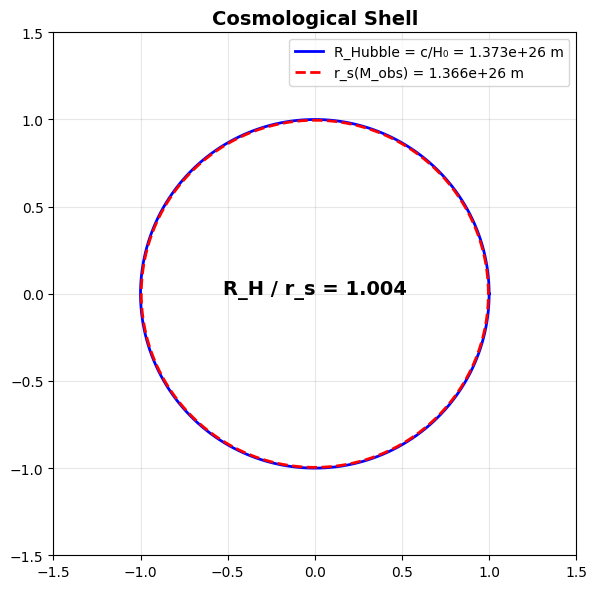

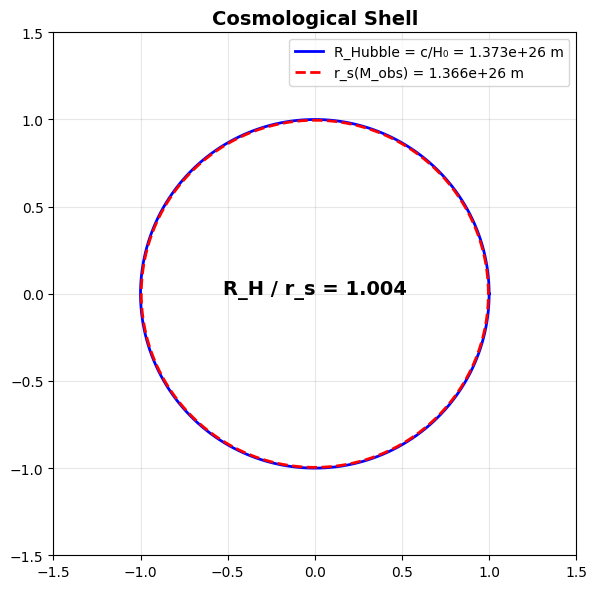

In [2]:
# Cosmological shell diagram
cosmological_shell_diagram(lang='en')

In [3]:
# Numerical calculations: cosmological shell
cosmo = CosmologicalModel()

print("=== Cosmological Shell (S 12.22) ===")
print(f"\nHubble radius R_H = c/H0 = {R_HUBBLE:.4e} m")
print(f"Hubble radius R_H = {R_HUBBLE / (PARSEC * 1e6):.1f} Mpc")
print(f"Hubble radius R_H = {R_HUBBLE / (9.461e15 * 1e9):.1f} Gly")

print(f"\nSchwarzschild radius of M_obs:")
print(f"  M_obs = {M_OBSERVABLE:.3e} kg")
print(f"  r_s   = {cosmo.r_s_observable:.4e} m")

ratio = cosmo.ratio_hubble_schwarzschild()
print(f"\nRatio R_H / r_s = {ratio:.4f}")
print(f"  --> {'Nearly equal!' if abs(ratio - 1) < 0.1 else 'Significant difference'}")

# Critical mass
M_crit = CosmologicalModel.schwarzschild_equals_hubble()
print(f"\nCritical mass (r_s = R_H): M_crit = {M_crit:.4e} kg")
print(f"  = {M_crit / M_SUN:.4e} solar masses")

# Critical density
print(f"\nCritical density rho_crit = {RHO_CRIT:.4e} kg/m^3")
print(f"  = {RHO_CRIT / 1.67e-27:.1f} protons/m^3")

# v_time at various distances
print("\nTime velocity at cosmological distances:")
for frac in [0.1, 0.3, 0.5, 0.7, 0.9, 0.99, 1.0]:
    d = frac * R_HUBBLE
    v_t = CosmologicalModel.c_local_cosmological(d)
    print(f"  d = {frac:.2f} R_H:  v_time = {v_t/C:.6f} c")

=== Cosmological Shell (S 12.22) ===

Hubble radius R_H = c/H0 = 1.3725e+26 m
Hubble radius R_H = 4448.0 Mpc
Hubble radius R_H = 14.5 Gly

Schwarzschild radius of M_obs:
  M_obs = 9.200e+52 kg
  r_s   = 1.3664e+26 m

Ratio R_H / r_s = 1.0045
  --> Nearly equal!

Critical mass (r_s = R_H): M_crit = 9.2410e+52 kg
  = 4.6461e+22 solar masses

Critical density rho_crit = 8.5327e-27 kg/m^3
  = 5.1 protons/m^3

Time velocity at cosmological distances:
  d = 0.10 R_H:  v_time = 0.994987 c
  d = 0.30 R_H:  v_time = 0.953939 c
  d = 0.50 R_H:  v_time = 0.866025 c
  d = 0.70 R_H:  v_time = 0.714143 c
  d = 0.90 R_H:  v_time = 0.435890 c
  d = 0.99 R_H:  v_time = 0.141067 c
  d = 1.00 R_H:  v_time = 0.000000 c


---
## 2. Observer Inside a Black Hole (\S 12.23)

The Oppenheimer-Snyder solution (1939) shows that the *interior* of a collapsing dust sphere
is described by an FLRW metric -- a mini-universe.

### Oppenheimer-Snyder Result

**Formula (72)** -- FLRW metric inside:
$$ds^2 = -c^2 d\tau^2 + a(\tau)^2 \left[\frac{dr^2}{1 - kr^2} + r^2 d\Omega^2\right] \tag{72}$$

### Friedmann Equation

**Formula (73)** -- Friedmann inside the black hole:
$$\left(\frac{\dot{a}}{a}\right)^2 = \frac{8\pi G \rho}{3} \tag{73}$$

### Analytic Continuation: $c_{\text{interior}}$

Outside the horizon: $c_{\text{local}} = c\sqrt{1 - r_s/r}$ (real for $r > r_s$).
Inside the horizon: $f(r) = 1 - r_s/r < 0$ -- $c_{\text{local}}$ becomes imaginary.

**Formula (74)** -- interior spacetime speed:
$$c_{\text{interior}}(r) = c \cdot \sqrt{\frac{r_s}{r} - 1} \quad \text{for } r < r_s \tag{74}$$

**Formula (75)** -- velocity identity inside/outside:
$$|f(r)| \cdot c^2 = |c_{\text{local}}^2| \quad \text{for all } r \neq r_s \tag{75}$$

| Region | $f(r)$ | $c_{\text{local}}$ | Interpretation |
|--------|--------|---------------------|----------------|
| $r \gg r_s$ | $\approx 1$ | $\approx c$ | Flat spacetime |
| $r > r_s$ | $0 < f < 1$ | $c\sqrt{f}$ | Gravity: $c_{\text{local}}$ decreases |
| $r = r_s$ | $0$ | $0$ | Event horizon: time frozen |
| $r < r_s$ | $< 0$ | $c\sqrt{|f|}$ | Roles swapped |

In [4]:
# Calculate c_interior for a 10 M_sun black hole
bh = GravityModel(10 * M_SUN)
rs = bh.rs

print("=== Observer Inside a Black Hole (S 12.23) ===")
print(f"\nBlack hole: M = 10 M_sun, r_s = {rs:.4e} m = {rs/1000:.1f} km")

print("\n--- c_local outside the horizon (r > r_s) ---")
for factor in [10.0, 5.0, 3.0, 2.0, 1.5, 1.1, 1.01]:
    r = factor * rs
    cl = bh.c_local(r)
    print(f"  r = {factor:.2f} r_s:  c_local = {cl/C:.6f} c")

print("\n--- c_interior inside the horizon (r < r_s) ---")
for factor in [0.99, 0.9, 0.8, 0.5, 0.3, 0.1, 0.01]:
    r = factor * rs
    ci = bh.c_interior(r)
    print(f"  r = {factor:.2f} r_s:  c_interior = {ci/C:.6f} c")

print("\n--- Velocity identity |f(r)| * c^2 = |c_local^2| ---")
for factor in [5.0, 2.0, 1.5, 0.5, 0.3, 0.1]:
    r = factor * rs
    f_r = bh.metric_function(r)
    if r > rs:
        c_val = bh.c_local(r)
    else:
        c_val = bh.c_interior(r)
    lhs = abs(f_r) * C**2
    rhs = c_val**2
    print(f"  r = {factor:.1f} r_s:  |f(r)| = {abs(f_r):.6f},  "
          f"|f|*c^2 = {lhs:.6e},  c_val^2 = {rhs:.6e},  "
          f"match = {abs(lhs - rhs) / max(lhs, rhs, 1e-30) < 1e-10}")

=== Observer Inside a Black Hole (S 12.23) ===

Black hole: M = 10 M_sun, r_s = 2.9541e+04 m = 29.5 km

--- c_local outside the horizon (r > r_s) ---
  r = 10.00 r_s:  c_local = 0.948683 c
  r = 5.00 r_s:  c_local = 0.894427 c
  r = 3.00 r_s:  c_local = 0.816497 c
  r = 2.00 r_s:  c_local = 0.707107 c
  r = 1.50 r_s:  c_local = 0.577350 c
  r = 1.10 r_s:  c_local = 0.301511 c
  r = 1.01 r_s:  c_local = 0.099504 c

--- c_interior inside the horizon (r < r_s) ---
  r = 0.99 r_s:  c_interior = 0.100504 c
  r = 0.90 r_s:  c_interior = 0.333333 c
  r = 0.80 r_s:  c_interior = 0.500000 c
  r = 0.50 r_s:  c_interior = 1.000000 c
  r = 0.30 r_s:  c_interior = 1.527525 c
  r = 0.10 r_s:  c_interior = 3.000000 c
  r = 0.01 r_s:  c_interior = 9.949874 c

--- Velocity identity |f(r)| * c^2 = |c_local^2| ---
  r = 5.0 r_s:  |f(r)| = 0.800000,  |f|*c^2 = 7.190041e+16,  c_val^2 = 7.190041e+16,  match = True
  r = 2.0 r_s:  |f(r)| = 0.500000,  |f|*c^2 = 4.493776e+16,  c_val^2 = 4.493776e+16,  match = 

In [ ]:
# Hyperexpansion: c_local and spatial stretching during shell convergence
print("=== Hyperexpansion at black hole formation (§12.23) ===")
print()
print("Spherical shell converges: R → r_s")
print(f"{'R / r_s':>10s}  {'c_local / c':>12s}  {'Stretching':>12s}  {'Expansion/info':>14s}")

for R_ratio in [100, 10, 3, 2, 1.5, 1.1, 1.01, 1.001]:
    c_loc = math.sqrt(1 - 1/R_ratio)
    stretch = 1/c_loc if c_loc > 0 else float('inf')
    ratio = 1/(c_loc**2) if c_loc > 0 else float('inf')
    print(f"{R_ratio:10.3f}  {c_loc:12.6f}  {stretch:12.2f}  {ratio:14.2f}")

# R = r_s: singular point
print(f"{'1.000':>10s}  {'0.000000':>12s}  {'∞':>12s}  {'∞':>14s}")
print()

# Era table: H(t) from M_BH
print("=== Cosmological eras from M_BH growth (formula 79) ===")
print()
print("H(t) = c³/(2G·M_BH(t))")
print()

# Example: M_BH at formation vs now
M_initial = 10 * M_SUN  # stellar black hole
M_now = C**3 / (2 * G * H_0)  # current universe
H_initial = C**3 / (2 * G * M_initial)

print(f"At formation (stellar BH, 10 M☉):")
print(f"  M_BH = {M_initial:.3e} kg")
print(f"  H    = {H_initial:.3e} s⁻¹")
print(f"  t_H  = 1/H = {1/H_initial:.3e} s = {1/H_initial/(365.25*86400):.6f} yr")
print()
print(f"Now (universe):")
print(f"  M_BH = {M_now:.3e} kg")
print(f"  H    = {H_0:.3e} s⁻¹")
print(f"  t_H  = 1/H = {1/H_0:.3e} s = {1/H_0/(365.25*86400*1e9):.1f} Gyr")
print()
print(f"Ratio H_formation / H_now = {H_initial/H_0:.3e}")
print(f"→ Inflation and current expansion: same mechanism, different scale")

#### Hyperexpansion at black hole formation

**Step 1 — the spherical shell and the shell theorem**

Consider a spherical light shell converging toward point O. In ORT,
the shell theorem gives: inside a uniform spherical shell with mass M and
radius R, c_local is **uniform** — no gradient, hence no force,
but time dilation and spatial stretching do occur:

**Formula (73b)** — c_local inside a spherical shell:
$$c_{\text{local,inside}} = c \cdot \sqrt{1 - r_s/R} \qquad (73b)$$

Because c_local is uniform:
- **No force** — consistent with the shell theorem
- **Time dilation present** — clocks tick slower than at infinity
- **Spatial stretching present** — isotropic, equal in all directions
- **Homogeneous and isotropic** — the cosmological principle follows automatically

**Step 2 — the shell converges: R → r_s**

| R | c_local | Spatial stretching | Information transfer |
|---|---------|-------------------|---------------------|
| ≫ r_s | ≈ c | ≈ 1 (flat) | ≈ c |
| 2r_s | c/√2 ≈ 0.71c | √2 ≈ 1.41 | 0.71c |
| 1.01 r_s | 0.1c | 10 | 0.1c |
| r_s | 0 | ∞ | 0 |

At the moment R = r_s: space expands infinitely fast while information
can no longer be exchanged. This is a **hyperexpansion**.

**Step 3 — two perspectives, same physics**

| External (c_local picture) | Internal (Friedmann picture) |
|---|---|
| c_local → 0 | H → ∞ (Big Bang) |
| Space stretches ∝ c/c_local | Scale factor a → 0 |
| Causal disconnection | Hubble horizon R_H → 0 |
| After formation: c_local recovers | After Big Bang: H decreases, a grows |

**Step 4 — Friedmann in ORT terms**

The three cosmological eras translate directly to c_local behavior.
Inflation and the current accelerated expansion are **the same mechanism**:
a (nearly) constant $M_{BH}$ gives a constant H and thus exponential
expansion. The only difference is scale.

**Formula (73c)** — exponential expansion at constant $M_{BH}$:
$$M_{BH} \approx \text{const} \;\Rightarrow\; H \approx \text{const} \;\Rightarrow\; a(\tau) \propto \exp(H\tau) \qquad (73c)$$

| Era | $M_{BH}(t)$ | H(t) | a(t) | c_local behavior |
|-----|---------|------|------|-----------------|
| Inflation | ≈ const (just formed) | ≈ const (large) | $\exp(Ht)$ | Decreases: hyperexpansion |
| Radiation | ∝ t | ∝ 1/t | $\propto t^{1/2}$ | Increases: recovery |
| Matter | ∝ t | ∝ 1/t | $\propto t^{2/3}$ | Increases: deceleration |
| Dark energy | ≈ const | ≈ const | $\exp(Ht)$ | Decreases: renewed expansion |

**Step 5 — self-sustaining expansion (no Λ needed)**

The expansion is **self-sustaining** through positive feedback:

1. The event horizon at $r_s$ has $c_{\text{local}} = 0$
2. Information travels at most $c_{\text{local}}$
3. Stretching space → larger distances → signals take longer
4. But $c_{\text{local}}$ also decreases → signals also travel slower
5. **Feedback**: expansion increases distances faster than information can bridge them

This is dark energy without Λ: no external energy source, no
scalar field — only a geometric consequence of the causal structure.

---
## 3. Is Our Universe Inside a Black Hole? (\S 12.24)

> **Hypothesis** -- not a proven result. Based on the striking correspondence
> between the BH interior and our universe.

### FLRW Scale Factor

**Formula (76)** -- scale factor (matter-dominated):
$$a(t) = a_0 \cdot \left(\frac{t}{t_0}\right)^{2/3} \tag{76}$$

This is both the standard Einstein-de Sitter scale factor and the solution
for the interior of an Oppenheimer-Snyder collapse.

### Redshift Correspondence

**Formula (77)** -- cosmological = gravitational redshift:
$$1 + z_{\text{cosmo}} = \frac{a(t_{\text{obs}})}{a(t_{\text{emit}})} = \frac{1}{\sqrt{f(r)}} \tag{77}$$

### Cosmological $c_{\text{local}}$

**Formula (78)** -- cosmological $c_{\text{local}}$ (speculative):
$$c_{\text{local}}(t) = c \cdot \sqrt{1 - \frac{H(t)^2 d^2}{c^2}} \tag{78}$$

> **Speculative**: extrapolates the ORT principle to cosmological scales.

### Comparison Table: Big Bang vs. Black Hole Interior

| Observable | Big Bang (LCDM) | BH Interior | Match |
|------------|-----------------|-------------|-------|
| Homogeneous space | Cosmological principle | Oppenheimer-Snyder | Yes |
| Scale factor $a(t)$ | Friedmann equation | Friedmann equation | Identical |
| Horizon at distance $c$ | Hubble horizon | Event horizon | Yes |
| Singularity | Big Bang ($t = 0$) | Collapse singularity | Yes (in past) |
| Redshift | Cosmological ($z$) | Gravitational ($z$) | Mathematically equal |
| Flatness ($\Omega \approx 1$) | "Fine-tuning problem" | Automatic: $r_s = R_H$ | Explained |

In [5]:
# Scale factor calculation
print("=== Scale Factor a(t) (S 12.24) ===")
print(f"Age of universe: t_0 = {T_UNIVERSE:.4e} s = {T_UNIVERSE/(365.25*86400*1e9):.2f} Gyr")

print("\nScale factor a(t) = (t/t_0)^(2/3) (matter-dominated):")
for t_frac in [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]:
    t = t_frac * T_UNIVERSE
    a = CosmologicalModel.scale_factor(t)
    z = 1/a - 1 if a > 0 else float('inf')
    print(f"  t = {t_frac:.2f} t_0:  a(t) = {a:.4f},  z = {z:.2f}")

# Cosmological c_local at various distances
print("\nCosmological c_local (formula 78):")
for d_frac in [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    d = d_frac * R_HUBBLE
    c_loc = CosmologicalModel.c_local_cosmological(d)
    print(f"  d = {d_frac:.2f} R_H:  c_local = {c_loc/C:.6f} c")

=== Scale Factor a(t) (S 12.24) ===
Age of universe: t_0 = 4.3549e+17 s = 13.80 Gyr

Scale factor a(t) = (t/t_0)^(2/3) (matter-dominated):
  t = 0.01 t_0:  a(t) = 0.0464,  z = 20.54
  t = 0.10 t_0:  a(t) = 0.2154,  z = 3.64
  t = 0.30 t_0:  a(t) = 0.4481,  z = 1.23
  t = 0.50 t_0:  a(t) = 0.6300,  z = 0.59
  t = 0.70 t_0:  a(t) = 0.7884,  z = 0.27
  t = 0.90 t_0:  a(t) = 0.9322,  z = 0.07
  t = 1.00 t_0:  a(t) = 1.0000,  z = 0.00

Cosmological c_local (formula 78):
  d = 0.10 R_H:  c_local = 0.994987 c
  d = 0.30 R_H:  c_local = 0.953939 c
  d = 0.50 R_H:  c_local = 0.866025 c
  d = 0.70 R_H:  c_local = 0.714143 c
  d = 0.90 R_H:  c_local = 0.435890 c
  d = 0.99 R_H:  c_local = 0.141067 c


## §12.25 — Dark Matter and Dark Energy as Boundary Effects

> **Note**: this is the most speculative section. The formulas follow
> from the ORT framework but have not been experimentally confirmed.

If the universe is the interior of a BH with mass $M_{BH}(t)$:

**Hubble parameter from BH mass** (79):
$$H(t) = \frac{c^3}{2G \cdot M_{BH}(t)} \qquad (79)$$

**Accelerated expansion** ⟺ $M_{BH}$ grows (79b):
$$\frac{d^2a}{dt^2} > 0 \quad\Longleftrightarrow\quad \frac{dM_{BH}}{dt} \propto M_{BH}^\alpha \;(\alpha > 1) \qquad (79b)$$

**Effective cosmological constant** (80):
$$\Lambda_{eff} = 3H^2 \cdot \Omega_\Lambda \approx \frac{3c^6 \cdot \Omega_\Lambda}{4G^2 M_{BH}^2} \qquad (80)$$

**Boundary acceleration** (81):
$$g_{eff}(r) = g_{Newton}(r) + g_{boundary}(r) \qquad (81)$$
$$g_{boundary} \approx \frac{c^2}{R_H} \cdot \frac{r}{R_H} \qquad (81b)$$

### Honesty Table

| Claim | Basis | Status |
|-------|-------|--------|
| H(t) from BH mass | Mathematical consequence | Speculative |
| Λ_eff from BH growth | Qualitatively fitting | Speculative |
| g_boundary ↔ MOND a₀ | Order-of-magnitude | Highly speculative |
| No dark matter needed | Unproven | Hypothesis |

In [ ]:
# §12.25: Effective cosmological constant Λ_eff
cosmo = CosmologicalModel()

print("=== Effective cosmological constant Λ_eff (formula 80) ===")
print()

# Lambda for various BH masses
Lambda_obs = 1.1e-52  # m⁻², observed value

print(f"Observed Λ ≈ {Lambda_obs:.1e} m⁻²")
print()

print(f"{'M_BH [M☉]':>14s}  {'Λ_eff [m⁻²]':>14s}  {'Λ_eff/Λ_obs':>12s}")
for log_m in [20, 21, 22, 22.35, 23, 24]:
    m_bh = 10**log_m * M_SUN
    lam = cosmo.lambda_effective(m_bh)
    ratio = lam / Lambda_obs
    marker = "  ← M_obs" if abs(log_m - 22.35) < 0.1 else ""
    print(f"  10^{log_m:<5.2f} M☉  {lam:14.3e}  {ratio:12.2f}{marker}")

print()
print(f"At M_obs ≈ 10²² M☉, Λ_eff matches the right order of magnitude.")
print(f"This is not proof — it is a striking coincidence.")

In [ ]:
# §12.25: Boundary acceleration at galactic scales
cosmo = CosmologicalModel()

print("=== Boundary acceleration g_boundary (formula 81) ===")
print()

# MOND scale
a0_mond = 1.2e-10  # m/s², Milgrom's constant
a0_cosmo = C**2 / R_HUBBLE  # c²/R_H

print(f"MOND a₀ (Milgrom)   = {a0_mond:.2e} m/s²")
print(f"c²/R_H (ORT)        = {a0_cosmo:.2e} m/s²")
print(f"Ratio                = {a0_cosmo/a0_mond:.2f}")
print()

# Rotation curve table
print("--- Rotation curve: Newton vs ORT boundary effect ---")
print(f"{'r [kpc]':>10s}  {'g_Newton [m/s²]':>16s}  {'g_boundary [m/s²]':>18s}  {'g_bound/g_Newton':>16s}")

M_galaxy = 1e11 * M_SUN  # typical galaxy mass
for r_kpc in [1, 5, 10, 20, 50, 100]:
    r = r_kpc * 1e3 * PARSEC  # kpc → m
    g_newton = G * M_galaxy / r**2
    g_bound = cosmo.dark_matter_acceleration(r)
    ratio = g_bound / g_newton if g_newton > 0 else float('inf')
    print(f"{r_kpc:10d}  {g_newton:16.3e}  {g_bound:18.3e}  {ratio:16.4f}")

print()
print("At r > 20 kpc, g_boundary dominates → flat rotation curve")
print("without dark matter. However: this is HIGHLY speculative!")

---

## Summary

| § | Topic | Formulas | Status |
|---|---|---|---|
| 12.22 | Cosmological shell | (66)-(71) | Speculative |
| 12.23 | BH interior + hyperexpansion | (72)-(75), (73b)-(73c) | Speculative |
| 12.24 | Universe as BH | (76)-(78) | Speculative |
| 12.25 | Dark matter/energy | (79)-(81) | Highly speculative |

### Honesty

All sections in this notebook are **speculative**. They follow logically from the
ORT framework but have not been independently confirmed:

- §12.22–12.24: the analogy r_s ≈ R_H is mathematically correct but not unique to ORT
- §12.23: the hyperexpansion at BH formation is a new mechanism that describes inflation
  and dark energy as **the same phenomenon** — without an inflaton field or Λ
- §12.25: Λ_eff and g_boundary give the right order of magnitude, but that is not proof
- None of these predictions distinguish ORT from other cosmological models

**Next**: Notebook 05 covers the quantum mechanical connection (§13).